In [3]:
from pathlib import Path

finger_path = Path("../dataset/fingerTappingData")

for folder in ["CTRL", "PD", "MSA", "PSP"]:
    files = list((finger_path / folder).glob("*.mat"))
    print(f"{folder}: {len(files)} files")

CTRL: 52 files
PD: 68 files
MSA: 72 files
PSP: 76 files


In [4]:
from scipy.io import loadmat
import numpy as np

ctrl_file = list((finger_path / "CTRL").glob("*.mat"))[0]
pd_file = list((finger_path / "PD").glob("*.mat"))[0]

ctrl_data = loadmat(ctrl_file)
pd_data = loadmat(pd_file)

print("CTRL file:", ctrl_file.name)
print("\nCTRL variables:")

for key, value in ctrl_data.items():
    if not key.startswith("__"):
        print(
            f"{key:30s}",
            "shape =", np.shape(value),
            "type =", type(value)
        )

print("\n" + "=" * 60)

print("PD file:", pd_file.name)
print("\nPD variables:")

for key, value in pd_data.items():
    if not key.startswith("__"):
        print(
            f"{key:30s}",
            "shape =", np.shape(value),
            "type =", type(value)
        )

CTRL file: CTRLSR25_2.mat

CTRL variables:
diagnosis                      shape = (1,) type = <class 'numpy.ndarray'>
gyroThumbX                     shape = (1, 3079) type = <class 'numpy.ndarray'>
gyroThumbY                     shape = (1, 3079) type = <class 'numpy.ndarray'>
gyroThumbZ                     shape = (1, 3079) type = <class 'numpy.ndarray'>
gyroIndexX                     shape = (1, 3079) type = <class 'numpy.ndarray'>
gyroIndexY                     shape = (1, 3079) type = <class 'numpy.ndarray'>
gyroIndexZ                     shape = (1, 3079) type = <class 'numpy.ndarray'>
fs                             shape = (1, 1) type = <class 'numpy.ndarray'>
person_id                      shape = (1,) type = <class 'numpy.ndarray'>
trial_id                       shape = (1,) type = <class 'numpy.ndarray'>

PD file: PDZD06_5.mat

PD variables:
diagnosis                      shape = (1,) type = <class 'numpy.ndarray'>
gyroThumbX                     shape = (1, 3554) type = <class

In [5]:
print("CTRL sampling frequency:", ctrl_data["fs"].flatten()[0])
print("PD sampling frequency:", pd_data["fs"].flatten()[0])

print("\nCTRL diagnosis:", ctrl_data["diagnosis"])
print("PD diagnosis:", pd_data["diagnosis"])

print("\nCTRL gyro shape:")
for col in [
    "gyroThumbX",
    "gyroThumbY",
    "gyroThumbZ",
    "gyroIndexX",
    "gyroIndexY",
    "gyroIndexZ"
]:
    print(col, ctrl_data[col].shape)

print("\nFirst 10 Thumb Gyro X values:")
print(ctrl_data["gyroThumbX"].flatten()[:10])

CTRL sampling frequency: 200
PD sampling frequency: 200

CTRL diagnosis: ['CTRL']
PD diagnosis: ['PD']

CTRL gyro shape:
gyroThumbX (1, 3079)
gyroThumbY (1, 3079)
gyroThumbZ (1, 3079)
gyroIndexX (1, 3079)
gyroIndexY (1, 3079)
gyroIndexZ (1, 3079)

First 10 Thumb Gyro X values:
[-0.65774812 -0.0854601  -0.04289322 -0.10437871  0.02805157  0.25034526
  0.25034526  0.35912728  0.45372035  0.57669132]


In [6]:
gyro_features = [
    "gyroThumbX",
    "gyroThumbY",
    "gyroThumbZ",
    "gyroIndexX",
    "gyroIndexY",
    "gyroIndexZ"
]

WINDOW_SIZE = 500
MIN_VALID_RATIO = 0.90

In [8]:
def create_gyro_windows(data, window_size=500, min_valid_ratio=0.90):

    n_samples = data[gyro_features[0]].size
    windows = []

    for start in range(
        0,
        n_samples - window_size + 1,
        window_size
    ):

        window = {}

        for feature in gyro_features:
            signal = data[feature].flatten()

            window[feature] = signal[
                start:start + window_size
            ]

        # Check validity
        valid = np.ones(window_size, dtype=bool)

        for feature in gyro_features:
            valid &= np.isfinite(window[feature])

        valid_ratio = valid.mean()

        if valid_ratio >= min_valid_ratio:
            windows.append(window)

    return windows

In [9]:
def extract_gyro_features(window):

    features = {}

    for col in gyro_features:

        signal = window[col]

        # Basic statistics
        features[f"{col}_mean"] = np.mean(signal)
        features[f"{col}_std"] = np.std(signal)
        features[f"{col}_min"] = np.min(signal)
        features[f"{col}_max"] = np.max(signal)

        # RMS
        features[f"{col}_rms"] = np.sqrt(
            np.mean(signal ** 2)
        )

        # Dynamic features
        diff = np.diff(signal)

        features[f"{col}_mean_abs_change"] = np.mean(
            np.abs(diff)
        )

        features[f"{col}_max_abs_change"] = np.max(
            np.abs(diff)
        )

        # Zero crossing rate
        centered = signal - np.mean(signal)

        zero_crossings = np.sum(
            centered[:-1] * centered[1:] < 0
        )

        features[f"{col}_zero_crossing_rate"] = (
            zero_crossings / (len(signal) - 1)
        )

    return features

In [10]:
ctrl_windows = create_gyro_windows(ctrl_data)
pd_windows = create_gyro_windows(pd_data)

print("CTRL windows:", len(ctrl_windows))
print("PD windows:", len(pd_windows))

ctrl_features = extract_gyro_features(
    ctrl_windows[0]
)

print("\nNumber of features:", len(ctrl_features))

print("\nSample features:")
for key, value in list(ctrl_features.items())[:10]:
    print(key, "=", value)

CTRL windows: 6
PD windows: 7

Number of features: 48

Sample features:
gyroThumbX_mean = 0.014553142381474914
gyroThumbX_std = 1.4941972430298889
gyroThumbX_min = -5.2171336410760905
gyroThumbX_max = 3.9252856710431727
gyroThumbX_rms = 1.4942681135028266
gyroThumbX_mean_abs_change = 0.44288129780314345
gyroThumbX_max_abs_change = 4.062771955049377
gyroThumbX_zero_crossing_rate = 0.10220440881763528
gyroThumbY_mean = 0.018325266352853916
gyroThumbY_std = 3.6222970494041764


In [11]:
all_features = []

# -------------------------
# CTRL = 0
# -------------------------

ctrl_files = list((finger_path / "CTRL").glob("*.mat"))

for file in ctrl_files:

    data = loadmat(file)

    windows = create_gyro_windows(data)

    for window_id, window in enumerate(windows):

        features = extract_gyro_features(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 0

        all_features.append(features)


# -------------------------
# PD = 1
# -------------------------

pd_files = list((finger_path / "PD").glob("*.mat"))

for file in pd_files:

    data = loadmat(file)

    windows = create_gyro_windows(data)

    for window_id, window in enumerate(windows):

        features = extract_gyro_features(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 1

        all_features.append(features)


finger_df = pd.DataFrame(all_features)

print("Shape:", finger_df.shape)
print("Recordings:", finger_df["recording_id"].nunique())
print("CTRL recordings:", len(ctrl_files))
print("PD recordings:", len(pd_files))
print("NaN:", finger_df.isna().sum().sum())
print("Inf:", np.isinf(
    finger_df.select_dtypes(include=np.number)
).sum().sum())

Shape: (716, 51)
Recordings: 120
CTRL recordings: 52
PD recordings: 68
NaN: 0
Inf: 0


In [12]:
from sklearn.model_selection import train_test_split

feature_cols = [
    col for col in finger_df.columns
    if col not in [
        "recording_id",
        "window_id",
        "label"
    ]
]

recording_ids = finger_df["recording_id"].unique()

recording_labels = (
    finger_df
    .groupby("recording_id")["label"]
    .first()
)

train_ids, test_ids = train_test_split(
    recording_ids,
    test_size=0.20,
    random_state=42,
    stratify=recording_labels
)

train_df = finger_df[
    finger_df["recording_id"].isin(train_ids)
].copy()

test_df = finger_df[
    finger_df["recording_id"].isin(test_ids)
].copy()

print("Train recordings:", len(train_ids))
print("Test recordings:", len(test_ids))

print("Train windows:", len(train_df))
print("Test windows:", len(test_df))

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Train recordings: 96
Test recordings: 24
Train windows: 585
Test windows: 131

Train labels:
label
1    335
0    250
Name: count, dtype: int64

Test labels:
label
1    79
0    52
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_cv = train_df[feature_cols]
y_cv = train_df["label"]
groups = train_df["recording_id"]

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_cv, y_cv, groups=groups),
    start=1
):

    X_fold_train = X_cv.iloc[train_idx]
    y_fold_train = y_cv.iloc[train_idx]

    X_fold_val = X_cv.iloc[val_idx]

    fold_val_df = train_df.iloc[val_idx].copy()

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        X_fold_train,
        y_fold_train
    )

    # Window predictions
    val_pred = rf.predict(X_fold_val)

    fold_results = fold_val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    # Window → recording
    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    # PD window ratio
    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    # Recording-level prediction
    recording_fold["final_prediction"] = (
        recording_fold["pd_ratio"] >= 0.5
    ).astype(int)

    score = accuracy_score(
        recording_fold["actual_label"],
        recording_fold["final_prediction"]
    )

    fold_scores.append(score)

    print(
        f"Finger Tapping Fold {fold}: "
        f"{score:.4f} "
        f"({score * 100:.2f}%)"
    )

print(
    "\nFinger Tapping CV Mean:",
    np.mean(fold_scores)
)

print(
    "Finger Tapping CV Std:",
    np.std(fold_scores)
)

Finger Tapping Fold 1: 1.0000 (100.00%)
Finger Tapping Fold 2: 0.9500 (95.00%)
Finger Tapping Fold 3: 0.9474 (94.74%)
Finger Tapping Fold 4: 1.0000 (100.00%)
Finger Tapping Fold 5: 0.9474 (94.74%)

Finger Tapping CV Mean: 0.9689473684210526
Finger Tapping CV Std: 0.025372570090934656


In [15]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print(
    "Finger Tapping Recording-level accuracy:",
    accuracy_score(
        recording_test["actual_label"],
        recording_test["final_prediction"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        recording_test["actual_label"],
        recording_test["final_prediction"]
    )
)

print("\nClassification Report:")
print(
    classification_report(
        recording_test["actual_label"],
        recording_test["final_prediction"],
        target_names=["CTRL", "PD"]
    )
)

Finger Tapping Recording-level accuracy: 1.0

Confusion Matrix:
[[10  0]
 [ 0 14]]

Classification Report:
              precision    recall  f1-score   support

        CTRL       1.00      1.00      1.00        10
          PD       1.00      1.00      1.00        14

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



In [16]:
# Check person IDs in train and test

def get_person_id(file):
    data = loadmat(file)
    return str(data["person_id"].flatten()[0])


train_persons = set()
test_persons = set()

for file in ctrl_files + pd_files:

    person_id = get_person_id(file)

    if file.name in train_ids:
        train_persons.add(person_id)

    if file.name in test_ids:
        test_persons.add(person_id)


overlap = train_persons.intersection(test_persons)

print("Train persons:", len(train_persons))
print("Test persons:", len(test_persons))
print("Person overlap:", len(overlap))
print("Overlapping IDs:", overlap)

Train persons: 25
Test persons: 16
Person overlap: 16
Overlapping IDs: {'PDZD06', 'PDVD19', 'PDJP10', 'PDRM21', 'CTRLNS10', 'CTRLDM02', 'CTRLMS08', 'PDZD05', 'CTRLNR02', 'PDSD06', 'CTRLSR25', 'PDRL04', 'PDMI09', 'CTRLJB05', 'CTRLAM21', 'PDBS13'}


In [18]:
# Build recording → person mapping

recording_person = {}

all_files = ctrl_files + pd_files

for file in all_files:
    data = loadmat(file)

    person_id = str(
        data["person_id"].flatten()[0]
    )

    recording_person[file.name] = person_id

print("Unique persons:",
    len(set(recording_person.values())))

Unique persons: 25


In [19]:
# Map every recording to its person_id and label

recording_info = []

for file in ctrl_files + pd_files:

    data = loadmat(file)

    person_id = str(
        data["person_id"].flatten()[0]
    )

    label = 0 if file.parent.name == "CTRL" else 1

    recording_info.append({
        "recording_id": file.name,
        "person_id": person_id,
        "label": label
    })

recording_info = pd.DataFrame(recording_info)

print("Recordings:", len(recording_info))
print("Unique persons:", recording_info["person_id"].nunique())

print("\nPersons by class:")
print(
    recording_info
    .groupby("label")["person_id"]
    .nunique()
)

Recordings: 120
Unique persons: 25

Persons by class:
label
0    11
1    14
Name: person_id, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

person_info = (
    recording_info[
        ["person_id", "label"]
    ]
    .drop_duplicates("person_id")
)

train_persons, test_persons = train_test_split(
    person_info["person_id"],
    test_size=0.20,
    random_state=42,
    stratify=person_info["label"]
)

print("Train persons:", len(train_persons))
print("Test persons:", len(test_persons))

print(
    "Person overlap:",
    len(
        set(train_persons)
        & set(test_persons)
    )
)

Train persons: 20
Test persons: 5
Person overlap: 0


In [21]:
train_recordings = recording_info[
    recording_info["person_id"].isin(train_persons)
]["recording_id"]

test_recordings = recording_info[
    recording_info["person_id"].isin(test_persons)
]["recording_id"]

train_person_df = finger_df[
    finger_df["recording_id"].isin(train_recordings)
].copy()

test_person_df = finger_df[
    finger_df["recording_id"].isin(test_recordings)
].copy()

print("\nTrain persons:", train_person_df["recording_id"].nunique())
print("Test persons:", test_person_df["recording_id"].nunique())

print("Train windows:", len(train_person_df))
print("Test windows:", len(test_person_df))


Train persons: 98
Test persons: 22
Train windows: 570
Test windows: 146


In [22]:
# Rebuild unique person-level information

person_info = (
    recording_info[
        ["person_id", "label"]
    ]
    .drop_duplicates(subset=["person_id"])
    .reset_index(drop=True)
)

print("Total unique persons:", len(person_info))

print("\nPersons by class:")
print(
    person_info["label"].value_counts()
)

Total unique persons: 25

Persons by class:
label
1    14
0    11
Name: count, dtype: int64


In [23]:
from sklearn.model_selection import train_test_split

train_persons, test_persons = train_test_split(
    person_info["person_id"].values,
    test_size=0.20,
    random_state=42,
    stratify=person_info["label"]
)

print("Train persons:", len(train_persons))
print("Test persons:", len(test_persons))

print(
    "Person overlap:",
    len(
        set(train_persons)
        .intersection(set(test_persons))
    )
)

Train persons: 20
Test persons: 5
Person overlap: 0


In [24]:
train_recordings = recording_info[
    recording_info["person_id"].isin(train_persons)
]["recording_id"].tolist()

test_recordings = recording_info[
    recording_info["person_id"].isin(test_persons)
]["recording_id"].tolist()

train_person_df = finger_df[
    finger_df["recording_id"].isin(train_recordings)
].copy()

test_person_df = finger_df[
    finger_df["recording_id"].isin(test_recordings)
].copy()

print("\nTrain persons:", len(train_persons))
print("Test persons:", len(test_persons))

print("Train recordings:", len(train_recordings))
print("Test recordings:", len(test_recordings))

print("Train windows:", len(train_person_df))
print("Test windows:", len(test_person_df))


Train persons: 20
Test persons: 5
Train recordings: 98
Test recordings: 22
Train windows: 570
Test windows: 146


In [25]:
train_check = set(
    recording_info[
        recording_info["recording_id"].isin(train_recordings)
    ]["person_id"]
)

test_check = set(
    recording_info[
        recording_info["recording_id"].isin(test_recordings)
    ]["person_id"]
)

print("\nPerson overlap:", train_check & test_check)


Person overlap: set()


In [26]:
recording_to_person = dict(
    zip(
        recording_info["recording_id"],
        recording_info["person_id"]
    )
)

train_person_df["person_id"] = (
    train_person_df["recording_id"]
    .map(recording_to_person)
)

test_person_df["person_id"] = (
    test_person_df["recording_id"]
    .map(recording_to_person)
)

print(
    "Train person IDs:",
    train_person_df["person_id"].nunique()
)

print(
    "Test person IDs:",
    test_person_df["person_id"].nunique()
)

Train person IDs: 20
Test person IDs: 5


In [27]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_cv = train_person_df[feature_cols]
y_cv = train_person_df["label"]
groups_cv = train_person_df["person_id"]

cv_person = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

person_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(
    cv_person.split(
        X_cv,
        y_cv,
        groups=groups_cv
    ),
    start=1
):

    X_train_fold = X_cv.iloc[train_idx]
    y_train_fold = y_cv.iloc[train_idx]

    X_val_fold = X_cv.iloc[val_idx]

    val_df = train_person_df.iloc[val_idx].copy()

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    window_pred = model.predict(X_val_fold)

    val_df["prediction"] = window_pred

    recording_results = (
        val_df
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_results["pd_ratio"] = (
        recording_results["pd_windows"] /
        recording_results["total_windows"]
    )

    recording_results["final_prediction"] = (
        recording_results["pd_ratio"] >= 0.5
    ).astype(int)

    score = accuracy_score(
        recording_results["actual_label"],
        recording_results["final_prediction"]
    )

    person_cv_scores.append(score)

    print(
        f"Person-Level Fold {fold}: "
        f"{score:.4f} "
        f"({score * 100:.2f}%)"
    )

print(
    "\nPerson-Level CV Mean:",
    np.mean(person_cv_scores)
)

print(
    "Person-Level CV Std:",
    np.std(person_cv_scores)
)

Person-Level Fold 1: 1.0000 (100.00%)
Person-Level Fold 2: 0.7391 (73.91%)
Person-Level Fold 3: 1.0000 (100.00%)
Person-Level Fold 4: 0.4348 (43.48%)
Person-Level Fold 5: 0.7273 (72.73%)

Person-Level CV Mean: 0.7802371541501977
Person-Level CV Std: 0.20996440303005612


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# -----------------------------------------
# Final RF: train on all 20 training people
# -----------------------------------------

final_person_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_person_rf.fit(
    train_person_df[feature_cols],
    train_person_df["label"]
)

# -----------------------------------------
# Predict test windows
# -----------------------------------------

test_window_pred = final_person_rf.predict(
    test_person_df[feature_cols]
)

test_results = test_person_df[
    ["recording_id", "person_id", "label"]
].copy()

test_results["prediction"] = test_window_pred

# -----------------------------------------
# Window → recording-level prediction
# -----------------------------------------

recording_test = (
    test_results
    .groupby("recording_id")
    .agg(
        person_id=("person_id", "first"),
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

recording_test["pd_ratio"] = (
    recording_test["pd_windows"] /
    recording_test["total_windows"]
)

recording_test["final_prediction"] = (
    recording_test["pd_ratio"] >= 0.5
).astype(int)

# -----------------------------------------
# Recording-level performance
# -----------------------------------------

y_true = recording_test["actual_label"]
y_pred = recording_test["final_prediction"]

accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    f"Finger Tapping Person-Independent "
    f"Recording Accuracy: {accuracy:.4f} "
    f"({accuracy * 100:.2f}%)"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_true,
        y_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["CTRL", "PD"]
    )
)

print("\nTest persons:")
print(
    recording_test[
        ["person_id", "actual_label", "final_prediction"]
    ].drop_duplicates()
)

Finger Tapping Person-Independent Recording Accuracy: 0.7273 (72.73%)

Confusion Matrix:
[[ 3  6]
 [ 0 13]]

Classification Report:
              precision    recall  f1-score   support

        CTRL       1.00      0.33      0.50         9
          PD       0.68      1.00      0.81        13

    accuracy                           0.73        22
   macro avg       0.84      0.67      0.66        22
weighted avg       0.81      0.73      0.68        22


Test persons:
   person_id  actual_label  final_prediction
0   CTRLAM21             0                 1
5   CTRLZI04             0                 1
6   CTRLZI04             0                 0
9     PDBS13             1                 1
15    PDMI09             1                 1
18    PDTR06             1                 1


In [29]:
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier

X_tune = train_person_df[feature_cols]
y_tune = train_person_df["label"]
groups_tune = train_person_df["person_id"]

person_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=person_cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(
    X_tune,
    y_tune,
    groups=groups_tune
)

print("Best parameters:")
print(grid.best_params_)

print("\nBest person-grouped CV accuracy:")
print(
    f"{grid.best_score_:.4f} "
    f"({grid.best_score_ * 100:.2f}%)"
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters:
{'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}

Best person-grouped CV accuracy:
0.7798 (77.98%)


In [30]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Best tuned model from GridSearchCV
tuned_rf = grid.best_estimator_

# Train on ALL 20 training subjects
tuned_rf.fit(
    train_person_df[feature_cols],
    train_person_df["label"]
)

# Predict untouched test recordings
test_pred_tuned = tuned_rf.predict(
    test_person_df[feature_cols]
)

tuned_test_results = test_person_df[
    ["recording_id", "person_id", "label"]
].copy()

tuned_test_results["prediction"] = test_pred_tuned

# Window -> recording
tuned_recording_test = (
    tuned_test_results
    .groupby("recording_id")
    .agg(
        person_id=("person_id", "first"),
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

tuned_recording_test["pd_ratio"] = (
    tuned_recording_test["pd_windows"] /
    tuned_recording_test["total_windows"]
)

tuned_recording_test["final_prediction"] = (
    tuned_recording_test["pd_ratio"] >= 0.5
).astype(int)

# Final recording-level metrics
y_true = tuned_recording_test["actual_label"]
y_pred = tuned_recording_test["final_prediction"]

accuracy = accuracy_score(y_true, y_pred)

print(
    f"Tuned Finger Tapping Recording Accuracy: "
    f"{accuracy:.4f} ({accuracy * 100:.2f}%)"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(y_true, y_pred)
)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["CTRL", "PD"]
    )
)

Tuned Finger Tapping Recording Accuracy: 0.7273 (72.73%)

Confusion Matrix:
[[ 3  6]
 [ 0 13]]

Classification Report:
              precision    recall  f1-score   support

        CTRL       1.00      0.33      0.50         9
          PD       0.68      1.00      0.81        13

    accuracy                           0.73        22
   macro avg       0.84      0.67      0.66        22
weighted avg       0.81      0.73      0.68        22



In [31]:
from scipy.fft import rfft, rfftfreq
import numpy as np

In [32]:
def extract_fft_features(window, fs=200):

    features = {}

    for col in gyro_features:

        signal = np.asarray(
            window[col],
            dtype=float
        )

        # Remove DC component
        signal = signal - np.mean(signal)

        n = len(signal)

        # FFT
        fft_values = np.abs(rfft(signal))
        frequencies = rfftfreq(n, d=1 / fs)

        # Power spectrum
        power = fft_values ** 2

        # Ignore DC component
        if len(power) > 1:
            power_no_dc = power[1:]
            freq_no_dc = frequencies[1:]
        else:
            power_no_dc = power
            freq_no_dc = frequencies

        # Dominant frequency
        dominant_idx = np.argmax(power_no_dc)

        features[
            f"{col}_dominant_freq"
        ] = freq_no_dc[dominant_idx]

        # Dominant power
        features[
            f"{col}_dominant_power"
        ] = power_no_dc[dominant_idx]

        # Spectral entropy
        total_power = np.sum(power_no_dc)

        if total_power > 0:

            probability = (
                power_no_dc /
                total_power
            )

            probability = probability[
                probability > 0
            ]

            features[
                f"{col}_spectral_entropy"
            ] = -np.sum(
                probability *
                np.log2(probability)
            )

        else:

            features[
                f"{col}_spectral_entropy"
            ] = 0.0

    return features

In [33]:
fft_test = extract_fft_features(
    ctrl_windows[0],
    fs=200
)

print("FFT features:", len(fft_test))

for key, value in fft_test.items():
    print(
        f"{key}: {value}"
    )

FFT features: 18
gyroThumbX_dominant_freq: 8.8
gyroThumbX_dominant_power: 42331.766825681094
gyroThumbX_spectral_entropy: 4.808239406939477
gyroThumbY_dominant_freq: 4.4
gyroThumbY_dominant_power: 343544.72694567457
gyroThumbY_spectral_entropy: 4.044866024548258
gyroThumbZ_dominant_freq: 4.4
gyroThumbZ_dominant_power: 49535.19488322079
gyroThumbZ_spectral_entropy: 4.425664068952061
gyroIndexX_dominant_freq: 4.4
gyroIndexX_dominant_power: 310838.2359520877
gyroIndexX_spectral_entropy: 4.474090476802912
gyroIndexY_dominant_freq: 4.4
gyroIndexY_dominant_power: 2061222.283357268
gyroIndexY_spectral_entropy: 4.338793022118785
gyroIndexZ_dominant_freq: 4.4
gyroIndexZ_dominant_power: 26296.81337598923
gyroIndexZ_spectral_entropy: 5.198801108986135


In [34]:
all_features_v2 = []

# =========================
# CTRL = 0
# =========================

for file in ctrl_files:

    data = loadmat(file)

    windows = create_gyro_windows(data)

    for window_id, window in enumerate(windows):

        features = {}

        # 48 statistical + dynamic features
        basic_features = extract_gyro_features(window)
        features.update(basic_features)

        # 18 FFT features
        fft_features = extract_fft_features(
            window,
            fs=200
        )
        features.update(fft_features)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 0

        all_features_v2.append(features)


# =========================
# PD = 1
# =========================

for file in pd_files:

    data = loadmat(file)

    windows = create_gyro_windows(data)

    for window_id, window in enumerate(windows):

        features = {}

        # 48 statistical + dynamic features
        basic_features = extract_gyro_features(window)
        features.update(basic_features)

        # 18 FFT features
        fft_features = extract_fft_features(
            window,
            fs=200
        )
        features.update(fft_features)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 1

        all_features_v2.append(features)


finger_v2 = pd.DataFrame(all_features_v2)

print("V2 shape:", finger_v2.shape)
print("Recordings:", finger_v2["recording_id"].nunique())

print(
    "Total features:",
    len([
        c for c in finger_v2.columns
        if c not in [
            "recording_id",
            "window_id",
            "label"
        ]
    ])
)

print(
    "NaN:",
    finger_v2.isna().sum().sum()
)

print(
    "Inf:",
    np.isinf(
        finger_v2.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

V2 shape: (716, 69)
Recordings: 120
Total features: 66
NaN: 0
Inf: 0


In [35]:
# Map recording -> person
finger_v2["person_id"] = (
    finger_v2["recording_id"]
    .map(recording_to_person)
)

# Use the EXACT same train/test persons as V1
train_v2 = finger_v2[
    finger_v2["person_id"].isin(train_persons)
].copy()

test_v2 = finger_v2[
    finger_v2["person_id"].isin(test_persons)
].copy()

v2_feature_cols = [
    col for col in finger_v2.columns
    if col not in [
        "recording_id",
        "window_id",
        "label",
        "person_id"
    ]
]

print("V2 train persons:", train_v2["person_id"].nunique())
print("V2 test persons:", test_v2["person_id"].nunique())

print("V2 train windows:", len(train_v2))
print("V2 test windows:", len(test_v2))

print("V2 features:", len(v2_feature_cols))

print(
    "Person overlap:",
    set(train_v2["person_id"])
    & set(test_v2["person_id"])
)

V2 train persons: 20
V2 test persons: 5
V2 train windows: 570
V2 test windows: 146
V2 features: 66
Person overlap: set()


In [36]:
X_v2 = train_v2[v2_feature_cols]
y_v2 = train_v2["label"]
groups_v2 = train_v2["person_id"]

cv_v2 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

v2_scores = []

for fold, (train_idx, val_idx) in enumerate(
    cv_v2.split(
        X_v2,
        y_v2,
        groups=groups_v2
    ),
    start=1
):

    X_train_fold = X_v2.iloc[train_idx]
    y_train_fold = y_v2.iloc[train_idx]

    X_val_fold = X_v2.iloc[val_idx]

    val_df = train_v2.iloc[val_idx].copy()

    rf_v2 = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf_v2.fit(
        X_train_fold,
        y_train_fold
    )

    window_pred = rf_v2.predict(
        X_val_fold
    )

    val_df["prediction"] = window_pred

    recording_results = (
        val_df
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_results["pd_ratio"] = (
        recording_results["pd_windows"] /
        recording_results["total_windows"]
    )

    recording_results["final_prediction"] = (
        recording_results["pd_ratio"] >= 0.5
    ).astype(int)

    score = accuracy_score(
        recording_results["actual_label"],
        recording_results["final_prediction"]
    )

    v2_scores.append(score)

    print(
        f"Finger Tapping V2 Fold {fold}: "
        f"{score:.4f} "
        f"({score * 100:.2f}%)"
    )

print(
    "\nFinger Tapping V2 CV Mean:",
    np.mean(v2_scores)
)

print(
    "Finger Tapping V2 CV Std:",
    np.std(v2_scores)
)

Finger Tapping V2 Fold 1: 0.9286 (92.86%)
Finger Tapping V2 Fold 2: 0.7391 (73.91%)
Finger Tapping V2 Fold 3: 1.0000 (100.00%)
Finger Tapping V2 Fold 4: 0.3913 (39.13%)
Finger Tapping V2 Fold 5: 0.7273 (72.73%)

Finger Tapping V2 CV Mean: 0.7572557876905703
Finger Tapping V2 CV Std: 0.21138674040208455


In [37]:
def create_gyro_windows_overlap(
    data,
    window_size=500,
    step=250,
    min_valid_ratio=0.90
):
    n_samples = data[gyro_features[0]].size

    windows = []

    for start in range(
        0,
        n_samples - window_size + 1,
        step
    ):

        window = {}

        for feature in gyro_features:

            signal = data[feature].flatten()

            window[feature] = signal[
                start:start + window_size
            ]

        # Check validity
        valid = np.ones(
            window_size,
            dtype=bool
        )

        for feature in gyro_features:
            valid &= np.isfinite(
                window[feature]
            )

        valid_ratio = valid.mean()

        if valid_ratio >= min_valid_ratio:
            windows.append(window)

    return windows

In [38]:
all_features_v3 = []

# =========================
# CTRL
# =========================

for file in ctrl_files:

    data = loadmat(file)

    windows = create_gyro_windows_overlap(
        data,
        window_size=500,
        step=250
    )

    for window_id, window in enumerate(windows):

        features = extract_gyro_features(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 0

        all_features_v3.append(features)


# =========================
# PD
# =========================

for file in pd_files:

    data = loadmat(file)

    windows = create_gyro_windows_overlap(
        data,
        window_size=500,
        step=250
    )

    for window_id, window in enumerate(windows):

        features = extract_gyro_features(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 1

        all_features_v3.append(features)


finger_v3 = pd.DataFrame(all_features_v3)

print("V3 shape:", finger_v3.shape)
print("Recordings:", finger_v3["recording_id"].nunique())

print(
    "Features:",
    len([
        c for c in finger_v3.columns
        if c not in [
            "recording_id",
            "window_id",
            "label"
        ]
    ])
)

print(
    "NaN:",
    finger_v3.isna().sum().sum()
)

print(
    "Inf:",
    np.isinf(
        finger_v3.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

V3 shape: (1354, 51)
Recordings: 120
Features: 48
NaN: 0
Inf: 0


In [39]:
finger_v3["person_id"] = (
    finger_v3["recording_id"]
    .map(recording_to_person)
)

train_v3 = finger_v3[
    finger_v3["person_id"].isin(train_persons)
].copy()

test_v3 = finger_v3[
    finger_v3["person_id"].isin(test_persons)
].copy()

v3_feature_cols = [
    c for c in finger_v3.columns
    if c not in [
        "recording_id",
        "window_id",
        "label",
        "person_id"
    ]
]

print("Train persons:", train_v3["person_id"].nunique())
print("Test persons:", test_v3["person_id"].nunique())

print("Train recordings:", train_v3["recording_id"].nunique())
print("Test recordings:", test_v3["recording_id"].nunique())

print("Train windows:", len(train_v3))
print("Test windows:", len(test_v3))

print("Features:", len(v3_feature_cols))

print(
    "Person overlap:",
    set(train_v3["person_id"])
    & set(test_v3["person_id"])
)

Train persons: 20
Test persons: 5
Train recordings: 98
Test recordings: 22
Train windows: 1073
Test windows: 281
Features: 48
Person overlap: set()


In [40]:
X_v3 = train_v3[v3_feature_cols]
y_v3 = train_v3["label"]
groups_v3 = train_v3["person_id"]

cv_v3 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

v3_scores = []

for fold, (train_idx, val_idx) in enumerate(
    cv_v3.split(
        X_v3,
        y_v3,
        groups=groups_v3
    ),
    start=1
):

    X_train_fold = X_v3.iloc[train_idx]
    y_train_fold = y_v3.iloc[train_idx]

    X_val_fold = X_v3.iloc[val_idx]

    val_df = train_v3.iloc[val_idx].copy()

    rf_v3 = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf_v3.fit(
        X_train_fold,
        y_train_fold
    )

    window_pred = rf_v3.predict(
        X_val_fold
    )

    val_df["prediction"] = window_pred

    recording_results = (
        val_df
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_results["pd_ratio"] = (
        recording_results["pd_windows"] /
        recording_results["total_windows"]
    )

    recording_results["final_prediction"] = (
        recording_results["pd_ratio"] >= 0.5
    ).astype(int)

    score = accuracy_score(
        recording_results["actual_label"],
        recording_results["final_prediction"]
    )

    v3_scores.append(score)

    print(
        f"V3 Fold {fold}: "
        f"{score:.4f} "
        f"({score * 100:.2f}%)"
    )

print(
    "\nV3 CV Mean:",
    np.mean(v3_scores)
)

print(
    "V3 CV Std:",
    np.std(v3_scores)
)

V3 Fold 1: 1.0000 (100.00%)
V3 Fold 2: 0.7600 (76.00%)
V3 Fold 3: 0.2381 (23.81%)
V3 Fold 4: 1.0000 (100.00%)
V3 Fold 5: 0.7273 (72.73%)

V3 CV Mean: 0.7450735930735931
V3 CV Std: 0.2784031848813401


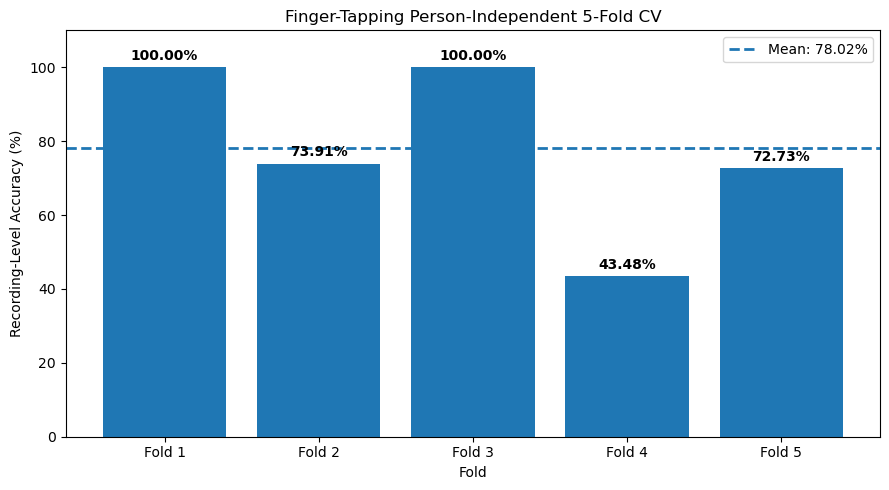

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Use the scores generated during CV
cv_scores = np.array(person_cv_scores) * 100

mean_cv = cv_scores.mean()
std_cv = cv_scores.std()

fold_labels = [
    f"Fold {i}"
    for i in range(1, len(cv_scores) + 1)
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    fold_labels,
    cv_scores
)

# Mean line
plt.axhline(
    mean_cv,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_cv:.2f}%"
)

# Values from actual CV results
for bar, score in zip(bars, cv_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 2,
        f"{score:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.xlabel("Fold")
plt.ylabel("Recording-Level Accuracy (%)")
plt.title("Finger-Tapping Person-Independent 5-Fold CV")

plt.ylim(0, 110)
plt.legend()

plt.tight_layout()

plt.savefig(
    "Finger_Tapping_CV_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

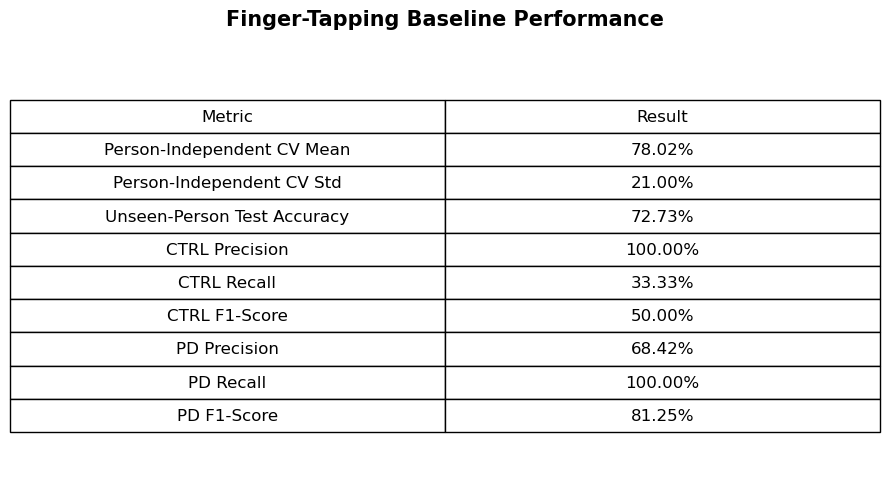

In [43]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt

# Actual metrics from final test predictions
test_accuracy = accuracy

pd_precision = precision_score(
    y_true,
    y_pred,
    pos_label=1
)

pd_recall = recall_score(
    y_true,
    y_pred,
    pos_label=1
)

pd_f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1
)

ctrl_precision = precision_score(
    y_true,
    y_pred,
    pos_label=0
)

ctrl_recall = recall_score(
    y_true,
    y_pred,
    pos_label=0
)

ctrl_f1 = f1_score(
    y_true,
    y_pred,
    pos_label=0
)

# Build table from calculated values
metrics = [
    ["Person-Independent CV Mean", f"{mean_cv:.2f}%"],
    ["Person-Independent CV Std", f"{std_cv:.2f}%"],
    ["Unseen-Person Test Accuracy", f"{test_accuracy * 100:.2f}%"],
    ["CTRL Precision", f"{ctrl_precision * 100:.2f}%"],
    ["CTRL Recall", f"{ctrl_recall * 100:.2f}%"],
    ["CTRL F1-Score", f"{ctrl_f1 * 100:.2f}%"],
    ["PD Precision", f"{pd_precision * 100:.2f}%"],
    ["PD Recall", f"{pd_recall * 100:.2f}%"],
    ["PD F1-Score", f"{pd_f1 * 100:.2f}%"],
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.axis("off")

table = ax.table(
    cellText=metrics,
    colLabels=["Metric", "Result"],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.8)

plt.title(
    "Finger-Tapping Baseline Performance",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "Finger_Tapping_Performance_Table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

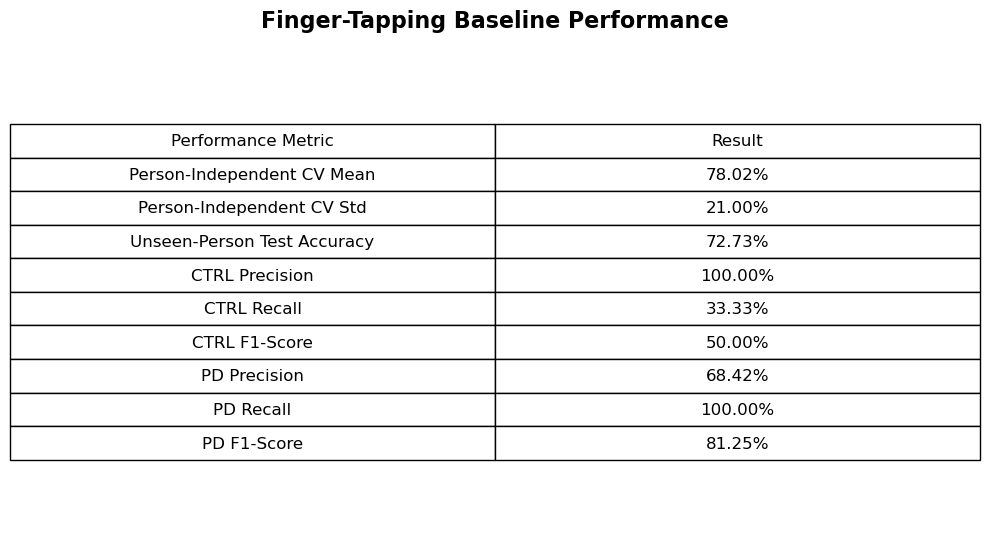

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# -----------------------------
# CV metrics
# -----------------------------
cv_scores = np.array(person_cv_scores)

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

# -----------------------------
# Test metrics
# -----------------------------
test_accuracy = accuracy_score(y_true, y_pred)

# CTRL = 0
ctrl_precision = precision_score(
    y_true, y_pred, pos_label=0
)

ctrl_recall = recall_score(
    y_true, y_pred, pos_label=0
)

ctrl_f1 = f1_score(
    y_true, y_pred, pos_label=0
)

# PD = 1
pd_precision = precision_score(
    y_true, y_pred, pos_label=1
)

pd_recall = recall_score(
    y_true, y_pred, pos_label=1
)

pd_f1 = f1_score(
    y_true, y_pred, pos_label=1
)

# -----------------------------
# Create table data
# -----------------------------
table_data = [
    ["Person-Independent CV Mean", f"{cv_mean * 100:.2f}%"],
    ["Person-Independent CV Std", f"{cv_std * 100:.2f}%"],
    ["Unseen-Person Test Accuracy", f"{test_accuracy * 100:.2f}%"],

    ["CTRL Precision", f"{ctrl_precision * 100:.2f}%"],
    ["CTRL Recall", f"{ctrl_recall * 100:.2f}%"],
    ["CTRL F1-Score", f"{ctrl_f1 * 100:.2f}%"],

    ["PD Precision", f"{pd_precision * 100:.2f}%"],
    ["PD Recall", f"{pd_recall * 100:.2f}%"],
    ["PD F1-Score", f"{pd_f1 * 100:.2f}%"],
]

# -----------------------------
# Plot table
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=["Performance Metric", "Result"],
    loc="center",
    cellLoc="center",
    colLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.8)

plt.title(
    "Finger-Tapping Baseline Performance",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "Finger_Tapping_Performance_Table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Confusion Matrix:
[[ 3  6]
 [ 0 13]]


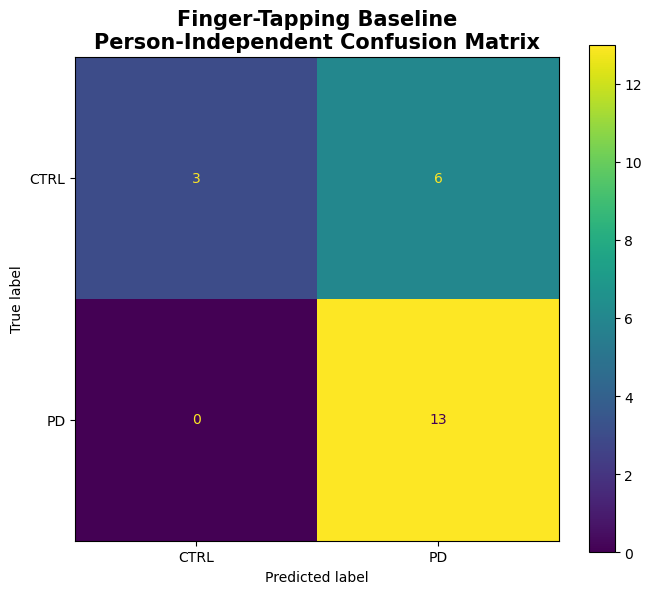

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Generate confusion matrix from actual predictions
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["CTRL", "PD"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Finger-Tapping Baseline\n"
    "Person-Independent Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Finger_Tapping_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()